In [ ]:
# 1. Import thư viện
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os
import cv2
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import classification_report, confusion_matrix

# Thiết lập mixed precision để tăng tốc trên GPU (nếu có)
tf.keras.mixed_precision.set_global_policy('mixed_float16')

2026-03-17 06:26:20.579912: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773728780.754361      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773728780.807334      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773728781.224498      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773728781.224536      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773728781.224539      55 computation_placer.cc:177] computation placer alr

In [2]:
# 2. Định nghĩa tham số
IMG_SIZE = 224          # Kích thước chuẩn của MobileNetV2
BATCH_SIZE = 64
EPOCHS = 10
NUM_CLASSES = 29        # A-Z + del + nothing + space
AUTOTUNE = tf.data.AUTOTUNE

# Đường dẫn dataset (thay đổi nếu cần)
data_dir = '/kaggle/input/datasets/debashishsau/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset'
train_dir = os.path.join(data_dir, 'asl_alphabet_train')
test_dir = os.path.join(data_dir, 'asl_alphabet_test')


In [3]:
# 3. Chuẩn bị dữ liệu
# 3.1. Tạo dataset cho training và validation từ train_dir
# Dùng image_dataset_from_directory để có performance tốt hơn
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Lấy tên các lớp
class_names = train_ds.class_names
print("Số lớp:", len(class_names))
print("Tên lớp:", class_names)

Found 223074 files belonging to 29 classes.
Using 178460 files for training.


I0000 00:00:1773728961.376492      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773728961.382481      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 223074 files belonging to 29 classes.
Using 44614 files for validation.
Số lớp: 29
Tên lớp: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


In [4]:
# 3.2. Data augmentation chỉ áp dụng cho tập train
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.2),
    layers.RandomTranslation(0.2, 0.2),
    layers.RandomZoom(0.2),
    layers.RandomFlip('horizontal'),
])

# Hàm áp dụng augmentation cho train dataset
def augment(image, label):
    image = data_augmentation(image, training=True)
    return image, label

train_ds = train_ds.map(lambda x, y: augment(x, y), num_parallel_calls=AUTOTUNE)
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [5]:
# 3.3. Tạo test dataset từ test_dir (các file .jpg riêng lẻ)
# Tạo dataframe chứa đường dẫn ảnh và nhãn từ tên file
test_images = []
test_labels = []
for fname in os.listdir(test_dir):
    if fname.endswith('.jpg'):
        # Tên file có dạng "A_test.jpg" -> nhãn "A"
        label = fname.split('_')[0]
        if label in class_names:
            test_images.append(os.path.join(test_dir, fname))
            test_labels.append(label)

# Tạo dataframe
test_df = pd.DataFrame({
    'filename': test_images,
    'class': test_labels
})

# Tạo ImageDataGenerator cho test (chỉ rescale)
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col='filename',
    y_col='class',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False   # giữ thứ tự để đánh giá
)


Found 28 validated image filenames belonging to 28 classes.


In [6]:
# 4. Xây dựng mô hình với Transfer Learning (MobileNetV2)
def create_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    # Load base model (pretrained on ImageNet)
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # Đóng băng ban đầu

    # Tạo model
    inputs = keras.Input(shape=input_shape)
    # Rescale (nếu dataset chưa được rescale, nhưng ở đây ta đã rescale qua dataset)
    # Nếu dùng image_dataset_from_directory, ảnh là float trong [0,255], cần rescale
    # Ta có thể rescale ở đây hoặc trong dataset. Trong dataset ta chưa rescale, nên thêm lớp Rescaling
    x = layers.Rescaling(1./255)(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    # Lớp cuối dùng float32 để ổn định với mixed precision
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = keras.Model(inputs, outputs)
    return model

model = create_model()

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593,373 (9.89 MB)

 Trainable params: 335,389 (1.28 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
# 5. Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_asl_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Theo dõi thời gian
class TimeHistory(keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()
    def on_epoch_end(self, epoch, logs=None):
        epoch_time = time.time() - self.epoch_start
        print(f"\n⏱️ Epoch {epoch+1} took {epoch_time:.2f} seconds")

callbacks.append(TimeHistory())


In [8]:
# 6. Huấn luyện
# Không cần steps_per_epoch vì dataset đã xác định số batch
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10


I0000 00:00:1773729022.980382     150 service.cc:152] XLA service 0x7abb2401fd90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773729022.980436     150 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773729022.980443     150 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773729024.677416     150 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1773729041.961922     150 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2789/2789 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.3086 - loss: 2.3564
Epoch 1: val_accuracy improved from -inf to 0.72733, saving model to best_asl_model.h5



⏱️ Epoch 1 took 1596.41 seconds
2789/2789 ━━━━━━━━━━━━━━━━━━━━ 1596s 561ms/step - accuracy: 0.3086 - loss: 2.3563 - val_accuracy: 0.7273 - val_loss: 0.9234 - learning_rate: 0.0010
Epoch 2/10
2788/2789 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.4993 - loss: 1.6161
Epoch 2: val_accuracy improved from 0.72733 to 0.76505, saving model to best_asl_model.h5



⏱️ Epoch 2 took 1349.87 seconds
2789/2789 ━━━━━━━━━━━━━━━━━━━━ 1350s 483ms/step - accuracy: 0.4993 - loss: 1.6161 - val_accuracy: 0.7651 - val_loss: 0.7723 - learning_rate: 0.0010
Epoch 3/10
2788/2789 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.5326 - loss: 1.5003
Epoch 3: val_accuracy improved from 0.76505 to 0.78428, saving model to best_asl_model.h5


...


⏱️ Epoch 4 took 1346.33 seconds
2789/2789 ━━━━━━━━━━━━━━━━━━━━ 1346s 482ms/step - accuracy: 0.5508 - loss: 1.4362 - val_accuracy: 0.7897 - val_loss: 0.6775 - learning_rate: 0.0010
Epoch 5/10
2788/2789 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.5617 - loss: 1.3988
Epoch 5: val_accuracy improved from 0.78971 to 0.79237, saving model to best_asl_model.h5



⏱️ Epoch 5 took 1339.77 seconds
2789/2789 ━━━━━━━━━━━━━━━━━━━━ 1340s 480ms/step - accuracy: 0.5617 - loss: 1.3987 - val_accuracy: 0.7924 - val_loss: 0.6629 - learning_rate: 0.0010
Epoch 6/10
2788/2789 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.5700 - loss: 1.3728
Epoch 6: val_accuracy improved from 0.79237 to 0.79926, saving model to best_asl_model.h5



⏱️ Epoch 6 took 1332.45 seconds
2789/2789 ━━━━━━━━━━━━━━━━━━━━ 1332s 477ms/step - accuracy: 0.5700 - loss: 1.3728 - val_accuracy: 0.7993 - val_loss: 0.6440 - learning_rate: 0.0010
Epoch 7/10
2788/2789 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.5727 - loss: 1.3583
Epoch 7: val_accuracy did not improve from 0.79926

⏱️ Epoch 7 took 1338.18 seconds
2789/2789 ━━━━━━━━━━━━━━━━━━━━ 1338s 479ms/step - accuracy: 0.5727 - loss: 1.3583 - val_accuracy: 0.7984 - val_loss: 0.6363 - learning_rate: 0.0010
Epoch 8/10
2788/2789 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.5778 - loss: 1.3359
Epoch 8: val_accuracy improved from 0.79926 to 0.80378, saving model to best_asl_model.h5



⏱️ Epoch 8 took 1339.53 seconds
2789/2789 ━━━━━━━━━━━━━━━━━━━━ 1340s 480ms/step - accuracy: 0.5778 - loss: 1.3359 - val_accuracy: 0.8038 - val_loss: 0.6169 - learning_rate: 0.0010
Epoch 9/10
2788/2789 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.5832 - loss: 1.3222
Epoch 9: val_accuracy improved from 0.80378 to 0.81277, saving model to best_asl_model.h5



⏱️ Epoch 9 took 1355.85 seconds
2789/2789 ━━━━━━━━━━━━━━━━━━━━ 1356s 486ms/step - accuracy: 0.5832 - loss: 1.3222 - val_accuracy: 0.8128 - val_loss: 0.5894 - learning_rate: 0.0010
Epoch 10/10
2788/2789 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.5860 - loss: 1.3114
Epoch 10: val_accuracy did not improve from 0.81277

⏱️ Epoch 10 took 1333.82 seconds
2789/2789 ━━━━━━━━━━━━━━━━━━━━ 1334s 478ms/step - accuracy: 0.5860 - loss: 1.3114 - val_accuracy: 0.8002 - val_loss: 0.6191 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 9.


In [9]:
# 7. Đánh giá trên test set
print("\nĐánh giá trên test set:")
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")


Đánh giá trên test set:


InvalidArgumentError: Graph execution error:

Detected at node compile_loss/categorical_crossentropy/softmax_cross_entropy_with_logits defined at (most recent call last):
<stack traces unavailable>
Dimensions cannot be made to match through broadcasting

Stack trace for op definition: 
File "<frozen runpy>", line 198, in _run_module_as_main
File "<frozen runpy>", line 88, in _run_code
File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start
File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever
File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once
File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run
File "/usr

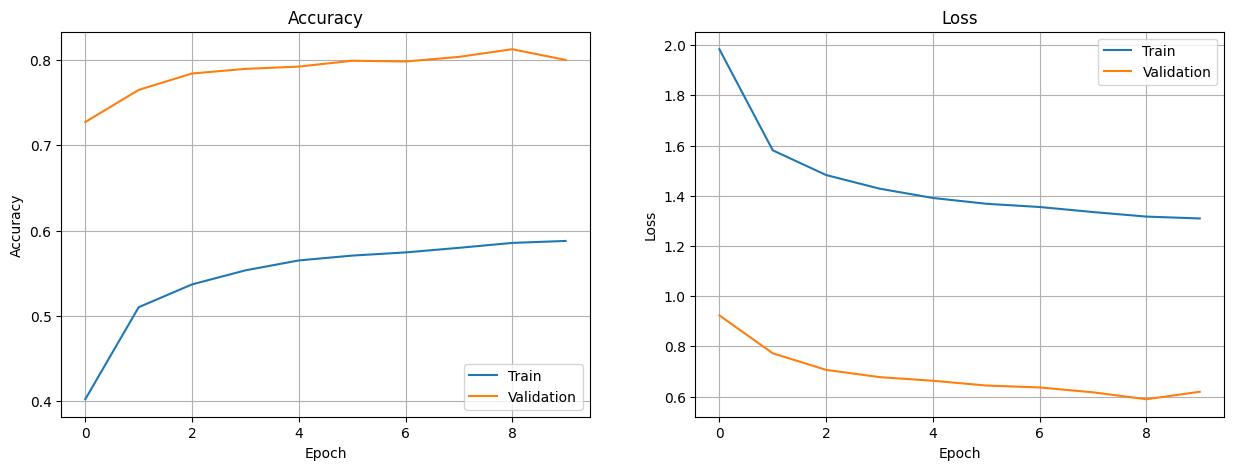

In [10]:
# 8. Vẽ đồ thị quá trình huấn luyện
def plot_training(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))
    ax1.plot(history.history['accuracy'], label='Train')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history.history['loss'], label='Train')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.show()

plot_training(history)

698/698 ━━━━━━━━━━━━━━━━━━━━ 51s 58ms/step

Classification Report (Validation Set):
              precision    recall  f1-score   support

           A       0.04      0.04      0.04      1734
           B       0.04      0.04      0.04      1726
           C       0.04      0.04      0.04      1659
           D       0.03      0.03      0.03      1485
           E       0.04      0.03      0.03      1516
           F       0.04      0.03      0.04      1587
           G       0.04      0.03      0.03      1566
           H       0.03      0.03      0.03      1552
           I       0.05      0.05      0.05      1570
           J       0.03      0.04      0.04      1498
           K       0.03      0.03      0.03      1614
           L       0.04      0.03      0.04      1621
           M       0.05      0.03      0.04      1595
           N       0.04      0.05      0.04      1617
           O       0.04      0.04      0.04      1645
           P       0.03      0.03      0.03      15

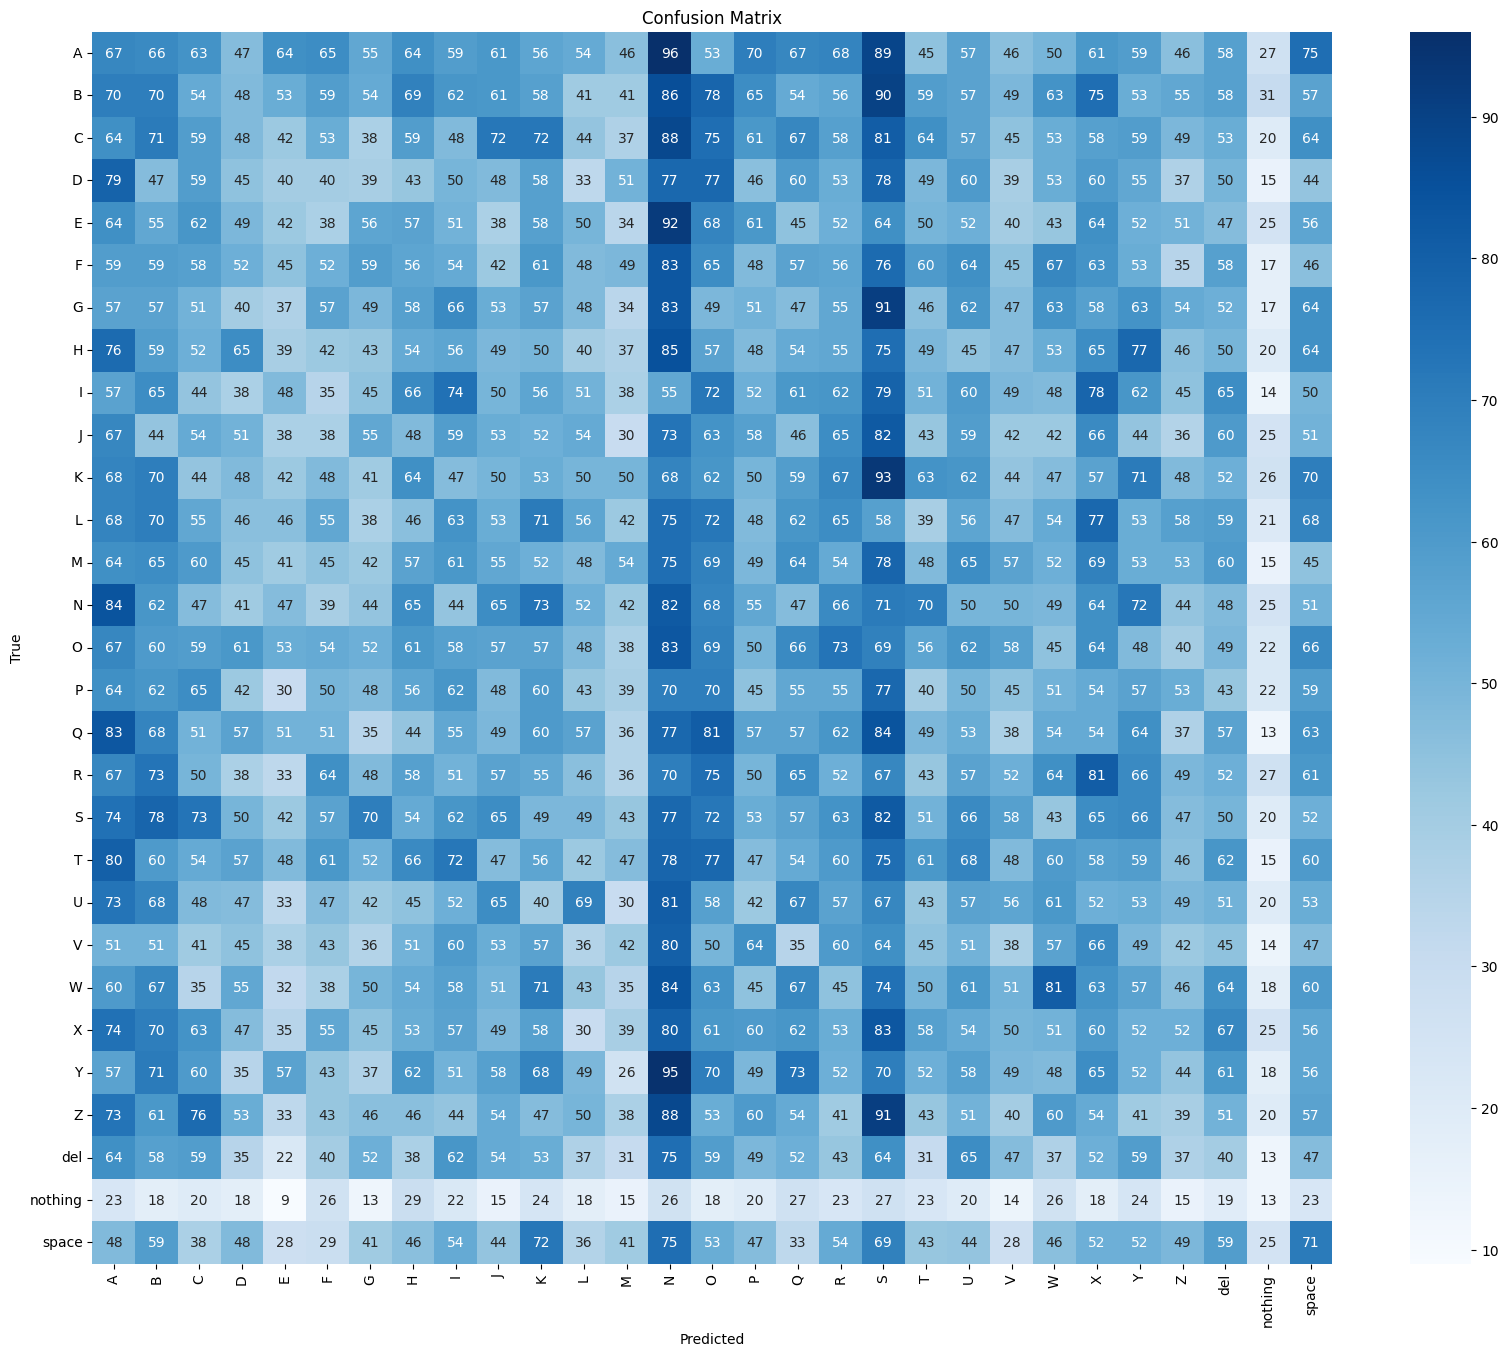

In [11]:
# 9. Phân tích chi tiết trên validation set (hoặc test)
# Lấy dự đoán trên validation set
val_labels = np.concatenate([y for x, y in val_ds], axis=0)
val_preds = model.predict(val_ds)
val_pred_classes = np.argmax(val_preds, axis=1)
val_true_classes = np.argmax(val_labels, axis=1)

# In classification report
print("\nClassification Report (Validation Set):")
print(classification_report(val_true_classes, val_pred_classes, target_names=class_names))

# Vẽ confusion matrix
cm = confusion_matrix(val_true_classes, val_pred_classes)
plt.figure(figsize=(20,16))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [13]:
# 10. Hàm dự đoán cho ảnh đơn
def predict_image(image_path, model, class_names, img_size=IMG_SIZE):
    """
    Dự đoán lớp cho một ảnh.
    """
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    img_array = img.astype('float32') / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)
    pred_class = np.argmax(preds[0])
    confidence = preds[0][pred_class]

    # Hiển thị kết quả
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title(f"Dự đoán: {class_names[pred_class]} ({confidence:.2f})")
    plt.axis('off')

    plt.subplot(1,2,2)
    top5_idx = np.argsort(preds[0])[-5:][::-1]
    top5_probs = preds[0][top5_idx]
    top5_labels = [class_names[i] for i in top5_idx]
    plt.barh(range(5), top5_probs)
    plt.yticks(range(5), top5_labels)
    plt.xlabel('Xác suất')
    plt.title('Top 5 dự đoán')
    plt.tight_layout()
    plt.show()

    return class_names[pred_class], confidence

# Ví dụ sử dụng (bỏ comment nếu muốn chạy thử)
# result, conf = predict_image('path_to_image.jpg', model, class_names)
# print(f"Kết quả: {result}, Độ tin cậy: {conf:.2f}")

In [14]:
# 11. Lưu mô hình và class names
model.save('asl_model_final.h5')
with open('class_names.pkl', 'wb') as f:
    pickle.dump(class_names, f)

print("Đã lưu mô hình và class names.")

Đã lưu mô hình và class names.


In [ ]:
# 12. (Tùy chọn) Fine-tuning: mở khóa một phần base model và huấn luyện tiếp
# base_model = model.layers[1]  # layer thứ hai là base_model (sau Rescaling)
# base_model.trainable = True
# # Đóng băng các layer đầu, chỉ fine-tune các layer cao
# for layer in base_model.layers[:100]:
#     layer.trainable = False
# # Compile lại với learning rate nhỏ
# model.compile(optimizer=keras.optimizers.Adam(1e-5),
#               loss='categorical_crossentropy',
#               metrics=['accuracy'])
# # Huấn luyện thêm vài epoch
# history_fine = model.fit(train_ds, epochs=5, validation_data=val_ds,
#                          callbacks=callbacks)